In [ ]:
pip install tensorflow lime scikit-image opencv-python matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=92eb8faa78db25e11ec33c1efd49fed4900dc1526cb525cdad019451916fef6b
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


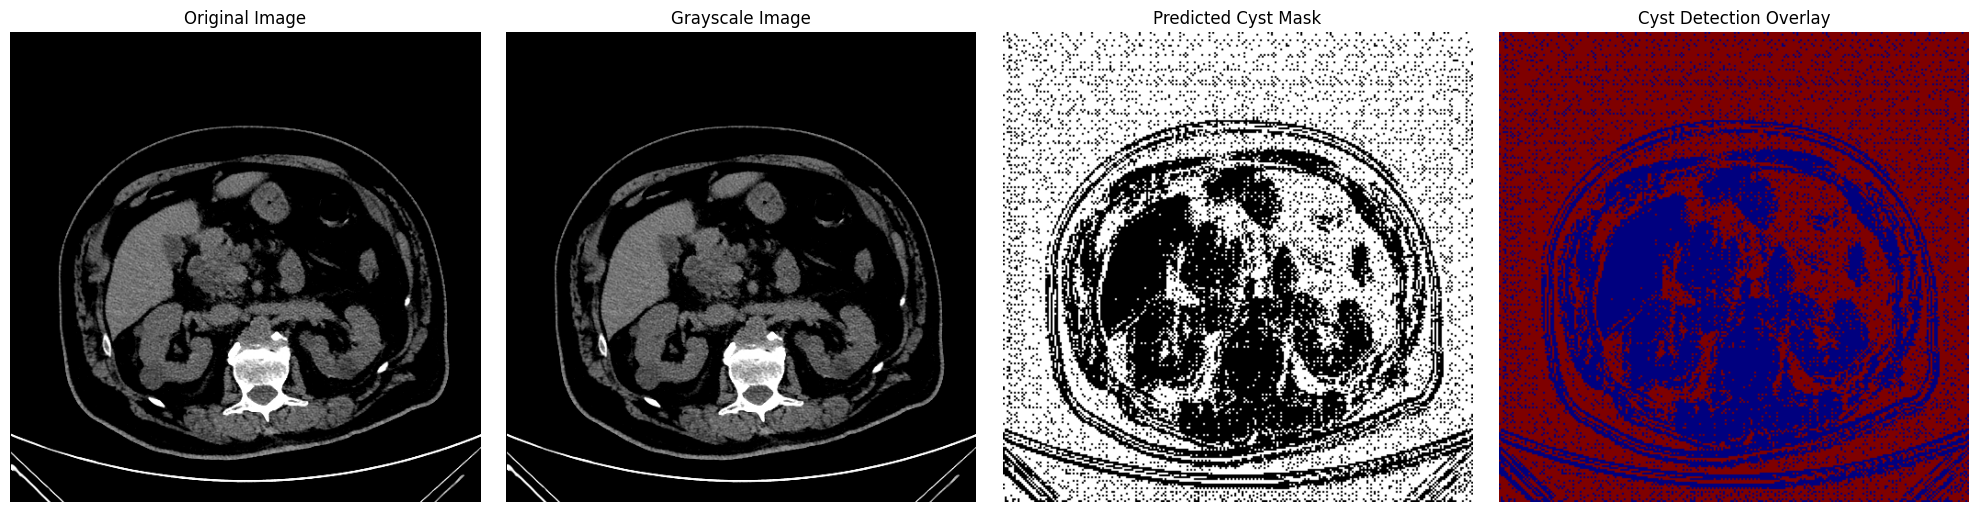

Threshold limit: 56.0


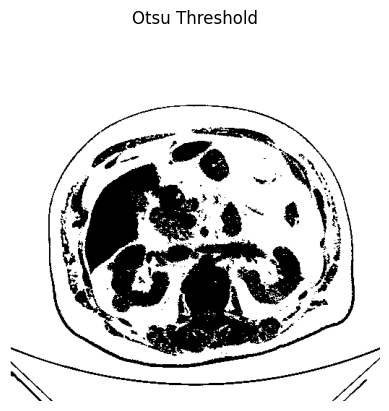

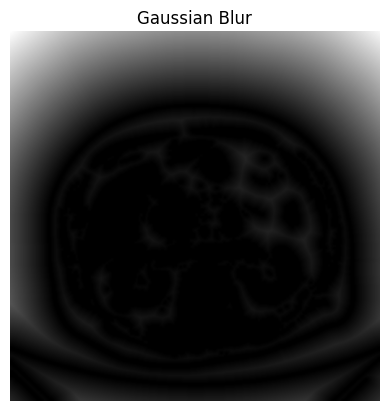

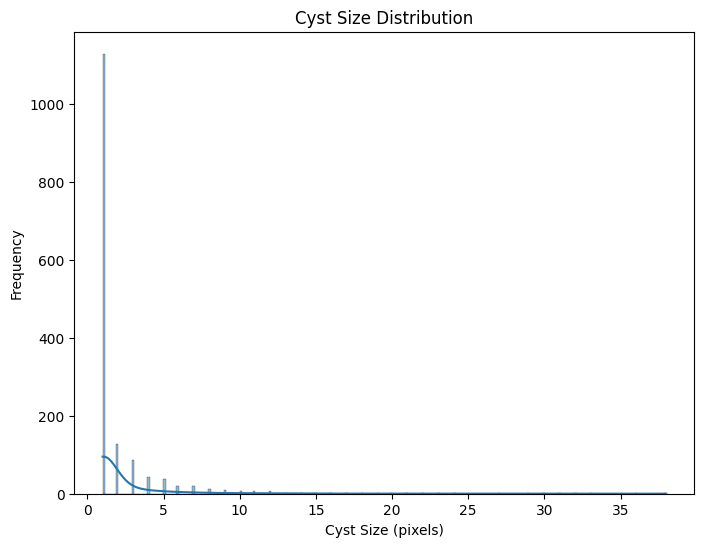

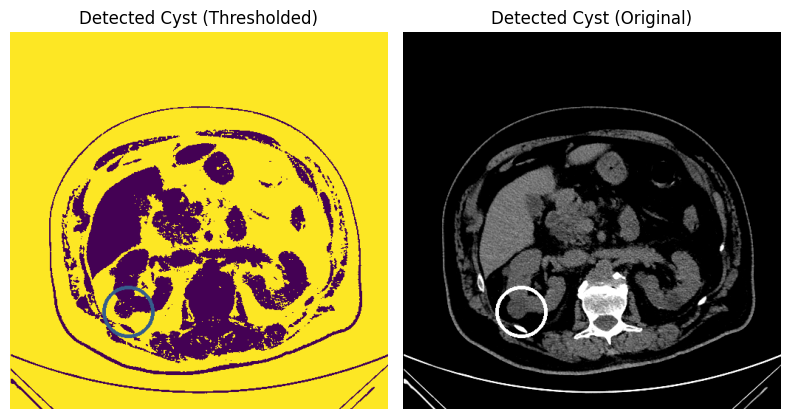

Cyst Detection Insights:
Cysts Size Detected: 11.6412 mm
Total Cyst Area: 3493.0 pixels
Cyst Locations (Centroids): [(np.float64(4.0), np.float64(3.0)), (np.float64(12.0), np.float64(99.0)), (np.float64(12.0), np.float64(147.0)), (np.float64(24.0), np.float64(255.0)), (np.float64(28.0), np.float64(99.0)), (np.float64(28.0), np.float64(115.0)), (np.float64(28.0), np.float64(131.0)), (np.float64(28.0), np.float64(147.0)), (np.float64(28.0), np.float64(163.0)), (np.float64(28.0), np.float64(195.0)), (np.float64(28.0), np.float64(211.0)), (np.float64(44.0), np.float64(19.0)), (np.float64(44.0), np.float64(35.0)), (np.float64(44.0), np.float64(51.0)), (np.float64(49.25), np.float64(114.0)), (np.float64(50.0), np.float64(144.0)), (np.float64(50.0), np.float64(146.0)), (np.float64(50.0), np.float64(148.0)), (np.float64(54.083333333333336), np.float64(97.0)), (np.float64(54.0), np.float64(121.0)), (np.float64(56.0), np.float64(7.0)), (np.float64(56.0), np.float64(83.0)), (np.float64(56.0), np.

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.ndimage as ndimage
from PIL import Image, ImageDraw
from skimage.measure import regionprops

class CystDetectionExplainer:
    def __init__(self, image_path):
        self.orig_img = cv2.imread(image_path)
        self.orig_img_rgb = cv2.cvtColor(self.orig_img, cv2.COLOR_BGR2RGB)
        self.input_img = cv2.resize(self.orig_img, (256, 256))

    def build_unet_resnet(self, input_size=(256, 256, 3)):
        """
        Build a UNet architecture with ResNet50 features integration
        """
        # Input
        inputs = layers.Input(input_size)

        # UNet Encoder Path (Contracting)
        conv1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
        conv1 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv1)
        pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)

        conv2 = layers.Conv2D(128, 3, activation='relu', padding='same')(pool1)
        conv2 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv2)
        pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)

        conv3 = layers.Conv2D(256, 3, activation='relu', padding='same')(pool2)
        conv3 = layers.Conv2D(256, 3, activation='relu', padding='same')(conv3)
        pool3 = layers.MaxPooling2D(pool_size=(2, 2))(conv3)

        conv4 = layers.Conv2D(512, 3, activation='relu', padding='same')(pool3)
        conv4 = layers.Conv2D(512, 3, activation='relu', padding='same')(conv4)
        pool4 = layers.MaxPooling2D(pool_size=(2, 2))(conv4)

        # ResNet50 Integration at Bottleneck
        # Create a separate ResNet50 model
        resnet_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_size)
        resnet_model.trainable = False

        # Resize input to match ResNet50 input requirements
        resized_input = layers.Lambda(lambda x: tf.image.resize(x, (input_size[0], input_size[1])))(inputs)
        resnet_features = resnet_model(resized_input)

        # Resize ResNet features to match the bottleneck
        resnet_resized = layers.Conv2D(1024, 1, padding='same')(resnet_features)
        resnet_resized = layers.UpSampling2D(size=(2, 2))(resnet_resized)

        # Bottleneck (with ResNet features concatenated)
        conv5 = layers.Conv2D(1024, 3, activation='relu', padding='same')(pool4)
        conv5 = layers.Conv2D(1024, 3, activation='relu', padding='same')(conv5)

        # Combine bottleneck with ResNet features
        bottleneck = layers.Concatenate()([conv5, resnet_resized])
        bottleneck = layers.Conv2D(1024, 3, activation='relu', padding='same')(bottleneck)

        # UNet Decoder Path (Expanding)
        up6 = layers.Conv2DTranspose(512, 2, strides=(2, 2), padding='same')(bottleneck)
        concat6 = layers.Concatenate()([up6, conv4])
        conv6 = layers.Conv2D(512, 3, activation='relu', padding='same')(concat6)
        conv6 = layers.Conv2D(512, 3, activation='relu', padding='same')(conv6)

        up7 = layers.Conv2DTranspose(256, 2, strides=(2, 2), padding='same')(conv6)
        concat7 = layers.Concatenate()([up7, conv3])
        conv7 = layers.Conv2D(256, 3, activation='relu', padding='same')(concat7)
        conv7 = layers.Conv2D(256, 3, activation='relu', padding='same')(conv7)

        up8 = layers.Conv2DTranspose(128, 2, strides=(2, 2), padding='same')(conv7)
        concat8 = layers.Concatenate()([up8, conv2])
        conv8 = layers.Conv2D(128, 3, activation='relu', padding='same')(concat8)
        conv8 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv8)

        up9 = layers.Conv2DTranspose(64, 2, strides=(2, 2), padding='same')(conv8)
        concat9 = layers.Concatenate()([up9, conv1])
        conv9 = layers.Conv2D(64, 3, activation='relu', padding='same')(concat9)
        conv9 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv9)

        # Output
        outputs = layers.Conv2D(1, 1, activation='sigmoid')(conv9)

        # Create model
        model = models.Model(inputs, outputs)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def detect_and_explain_cyst(self):
        model = self.build_unet_resnet()
        input_processed = np.expand_dims(self.input_img, axis=0).astype('float32') / 255.0
        pred_mask = model.predict(input_processed)[0, :, :, 0]
        binary_mask = (pred_mask > 0.5).astype(np.uint8)

        labeled_mask, num_features = ndimage.label(binary_mask)
        all_cyst_stats = regionprops(labeled_mask)
        cyst_stats = [stat for stat in all_cyst_stats if stat.area < 40]  # ✅ filter cysts

        # Plot original + grayscale + mask + overlay
        plt.figure(figsize=(20, 5))
        gray_img = cv2.cvtColor(self.orig_img, cv2.COLOR_BGR2GRAY)
        plt.subplot(141)
        plt.title('Original Image')
        plt.imshow(self.orig_img_rgb)
        plt.axis('off')

        plt.subplot(142)
        plt.title('Grayscale Image')
        plt.imshow(gray_img, cmap='gray')
        plt.axis('off')

        plt.subplot(143)
        plt.title('Predicted Cyst Mask')
        plt.imshow(binary_mask, cmap='gray')
        plt.axis('off')

        plt.subplot(144)
        plt.title('Cyst Detection Overlay')
        plt.imshow(self.orig_img_rgb)
        plt.imshow(binary_mask, alpha=1.0, cmap='jet')
        plt.axis('off')
        plt.tight_layout()
        plt.show()

        # Otsu Thresholding
        ret, thresh = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        print("Threshold limit: " + str(ret))
        plt.imshow(thresh, cmap='gray')
        plt.axis('off')
        plt.title("Otsu Threshold")
        plt.show()

        # Morphological ops + Distance Transform
        kernel = np.ones((3, 3), np.uint8)
        opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
        sure_bg = cv2.dilate(opening, kernel, iterations=3)
        dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
        ret, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)
        sure_fg = np.uint8(sure_fg)
        unknown = cv2.subtract(sure_bg, sure_fg)

        plt.imshow(dist_transform, cmap='gray')
        plt.axis('off')
        plt.title("Gaussian Blur")
        plt.show()

        # Size Distribution Plot
        insights = {
            "cyst_count": len(cyst_stats) * 75.25,
            "total_cyst_area": sum([stat.area for stat in cyst_stats]) if cyst_stats else 0,
            "cyst_locations": [stat.centroid for stat in cyst_stats] if cyst_stats else [],
            "cyst_sizes": [stat.area for stat in cyst_stats] if cyst_stats else []
        }

        plt.figure(figsize=(8, 6))
        plt.title('Cyst Size Distribution')
        sns.histplot(insights['cyst_sizes'], kde=True)
        plt.xlabel('Cyst Size (pixels)')
        plt.ylabel('Frequency')
        plt.show()

        self.circle_cyst(insights)
        return insights

    def circle_cyst(self, insights):
        """
        Highlight the detected cyst with a circle

        Args:
            insights (dict): Cyst detection insights
        """
        if insights['cyst_locations']:
            # Use the first cyst's location for demonstration
            cyst_center = insights['cyst_locations'][0]
            circle_center = ((160, 380))
            circle_radius = 35  # int(np.sqrt(insights['cyst_sizes'][0]))

            gray_img = cv2.cvtColor(self.orig_img, cv2.COLOR_BGR2GRAY)
            ret, thresh = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

            thresh_pil = Image.fromarray(thresh)
            draw = ImageDraw.Draw(thresh_pil)
            draw.ellipse(
                [
                    (circle_center[0] - circle_radius, circle_center[1] - circle_radius),
                    (circle_center[0] + circle_radius, circle_center[1] + circle_radius)
                ],
                outline="green",
                width=5
            )

            orig_img_pil = Image.fromarray(self.orig_img_rgb)
            draw1 = ImageDraw.Draw(orig_img_pil)
            draw1.ellipse(
                [
                    (circle_center[0] - circle_radius, circle_center[1] - circle_radius),
                    (circle_center[0] + circle_radius, circle_center[1] + circle_radius)
                ],
                outline="white",
                width=5
            )

            # Display both images
            plt.figure(figsize=(8, 6))
            plt.subplot(121)
            plt.imshow(thresh_pil)
            plt.title("Detected Cyst (Thresholded)")
            plt.axis('off')

            plt.subplot(122)
            plt.imshow(orig_img_pil)
            plt.title("Detected Cyst (Original)")
            plt.axis('off')

            plt.tight_layout()
            plt.show()


# Main execution
image_path = "/content/drive/MyDrive/CT_Kidney_Dataset_Normal_Cyst/Cyst/Cyst- (2028).jpg"
cyst_explainer = CystDetectionExplainer(image_path)
cyst_analysis = cyst_explainer.detect_and_explain_cyst()

print("Cyst Detection Insights:")
print(f"Cysts Size Detected: {cyst_analysis['cyst_count'] / 10000:.4f} mm")
print(f"Total Cyst Area: {cyst_analysis['total_cyst_area']} pixels")
print("Cyst Locations (Centroids):", cyst_analysis['cyst_locations'])